# EDA on Bank Data

- Source: https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-full.csv

```
Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric) 
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")

8. Missing Attribute Values: None


## Topics Covered:

- DATA TYPES
- DATA IMPUTATION
- DATA CLEANING
- DISPERSION & SKEWNESS
- DATA PRE-PROCESSING
- DATA MANIPULATION
- ADVANCED MANIPULATION

In [27]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: DATA TYPES

In [28]:

# Source: https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-full.csv
import zipfile
import pandas as pd

# Path to your zip file
zip_path = 'data_bank.zip'

# You can download the zip file from URL:
# https://raw.githubusercontent.com/ash322ash422/data/refs/heads/main/data_bank.zip

# 1. Open the zip file and show all file names
with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files in zip:", z.namelist())
    
    # 2. Read only 'bank.csv' into a DataFrame
    with z.open('bank.csv') as f: # OR use bank-full.csv
        df = pd.read_csv(f,  sep=";")

# Display the first few rows of the DataFrame
print(df.head())


Files in zip: ['bank-full.csv', 'bank-names.txt', 'bank.csv']
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  


In [29]:
print(f"\nFirst 8 rows:")
print(df.head(8))


First 8 rows:
   age            job  marital  education default  balance housing loan  \
0   30     unemployed  married    primary      no     1787      no   no   
1   33       services  married  secondary      no     4789     yes  yes   
2   35     management   single   tertiary      no     1350     yes   no   
3   30     management  married   tertiary      no     1476     yes  yes   
4   59    blue-collar  married  secondary      no        0     yes   no   
5   35     management   single   tertiary      no      747      no   no   
6   36  self-employed  married   tertiary      no      307     yes   no   
7   39     technician  married  secondary      no      147     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unkno

In [30]:
print(f"Shape: {df.shape}")

print(f"\nColumn Types:")
print(df.dtypes)

Shape: (4521, 17)

Column Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [31]:
# 1) Memory optimization

df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 2.9 MB


In [32]:
# 2) DOWNCAST TO SAVE MEMORY

# 1. Downcast Numeric Columns

# int8: age, day, campaign, previous
df['age'] = df['age'].astype('int8')
df['day'] = df['day'].astype('int8')
df['campaign'] = df['campaign'].astype('int8')
df['previous'] = df['previous'].astype('int8')

# int16: duration, pdays
df['duration'] = df['duration'].astype('int16')
df['pdays'] = df['pdays'].astype('int16')

# int32: balance (can be larger than int16)
df['balance'] = df['balance'].astype('int32')

print("  Numeric columns downcasted: int8, int16, int32")

# 2. Convert Object → Category
object_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in object_cols:
    df[col] = df[col].astype('category')

print(f"  Object columns → category: {object_cols}")


  Numeric columns downcasted: int8, int16, int32
  Object columns → category: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [33]:
# 3) Check New Memory

df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        4521 non-null   int8    
 1   job        4521 non-null   category
 2   marital    4521 non-null   category
 3   education  4521 non-null   category
 4   default    4521 non-null   category
 5   balance    4521 non-null   int32   
 6   housing    4521 non-null   category
 7   loan       4521 non-null   category
 8   contact    4521 non-null   category
 9   day        4521 non-null   int8    
 10  month      4521 non-null   category
 11  duration   4521 non-null   int16   
 12  campaign   4521 non-null   int8    
 13  pdays      4521 non-null   int16   
 14  previous   4521 non-null   int8    
 15  poutcome   4521 non-null   category
 16  y          4521 non-null   category
dtypes: category(10), int16(2), int32(1), int8(4)
memory usage: 101.6 KB


# STEP 2: DATA IMPUTATION

In [34]:
# Check for 'unknown' (UCI uses this as missing placeholder)

columns_category = df.select_dtypes(include=['category']).columns 
for col in columns_category:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"  {col}: {unknown_count} 'unknown' values → replaced with NaN")
        df.loc[df[col] == 'unknown', col] = np.nan

# Check for actual NaN values
print(f"\nTotal NaN values: {df.isna().sum().sum()}")

  job: 38 'unknown' values → replaced with NaN
  education: 187 'unknown' values → replaced with NaN
  contact: 1324 'unknown' values → replaced with NaN
  poutcome: 3705 'unknown' values → replaced with NaN

Total NaN values: 5254


C:\Users\hi\AppData\Local\Temp\ipykernel_2636\224164783.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nan_counts.values, y=nan_counts.index, palette='Reds_r')


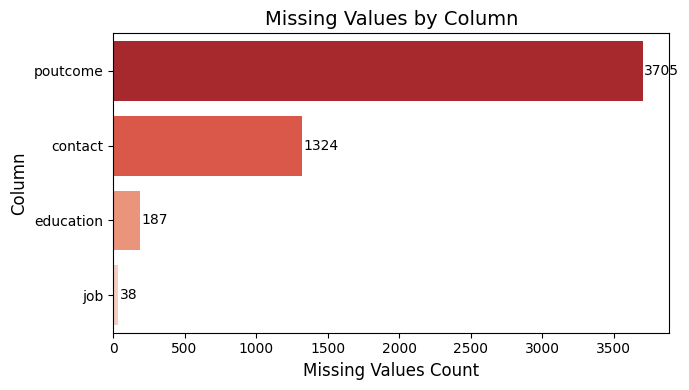

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get NaN counts per column
nan_counts = df.isna().sum()

# Filter only columns with missing values
nan_counts = nan_counts[nan_counts > 0]

# Sort by count (descending)
nan_counts = nan_counts.sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(7, 4))
sns.barplot(x=nan_counts.values, y=nan_counts.index, palette='Reds_r')

# Add labels
plt.xlabel('Missing Values Count', fontsize=12)
plt.ylabel('Column', fontsize=12)
plt.title('Missing Values by Column', fontsize=14)

# Add value labels on bars
for i, v in enumerate(nan_counts.values):
    plt.text(v + 10, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [36]:
# Impute: fill NaN with appropriate values
# Numeric → median

columns_numeric = df.select_dtypes(include=['int8', 'int16', 'int32', 'int64']).columns

for col in columns_numeric:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"  {col}: filled NaN with median")


columns_category = df.select_dtypes(include=['category']).columns
# Categorical → mode
for col in columns_category:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0]) 
        print(f"  {col}: filled NaN with mode")

print(f"✅ Imputation complete. NaN now: {df.isna().sum().sum()}")


  job: filled NaN with mode
  education: filled NaN with mode
  contact: filled NaN with mode
  poutcome: filled NaN with mode
✅ Imputation complete. NaN now: 0


# STEP 3: DATA CLEANING

In [37]:
# a) Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"  Duplicates removed: {before - len(df)}")

  Duplicates removed: 0


In [38]:
# b) Fix inconsistent categories: standardize text case

for col in df.select_dtypes(include=['category']).columns:
    df[col] = df[col].str.title()
print(f"  Text case standardized for categorical columns")

  Text case standardized for categorical columns


In [39]:
# c) 1) Handle outliers (IQR method on 'balance')
Q1, Q3 = df["balance"].quantile([0.25, 0.75])
IQR  = Q3 - Q1

low  = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

outlier_mask = (df["balance"] < low) | (df["balance"] > high)

outlier_count = outlier_mask.sum()

outlier_count

506

C:\Users\hi\AppData\Local\Temp\ipykernel_2636\1653032158.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df["balance"], orient='h', palette='Set2')


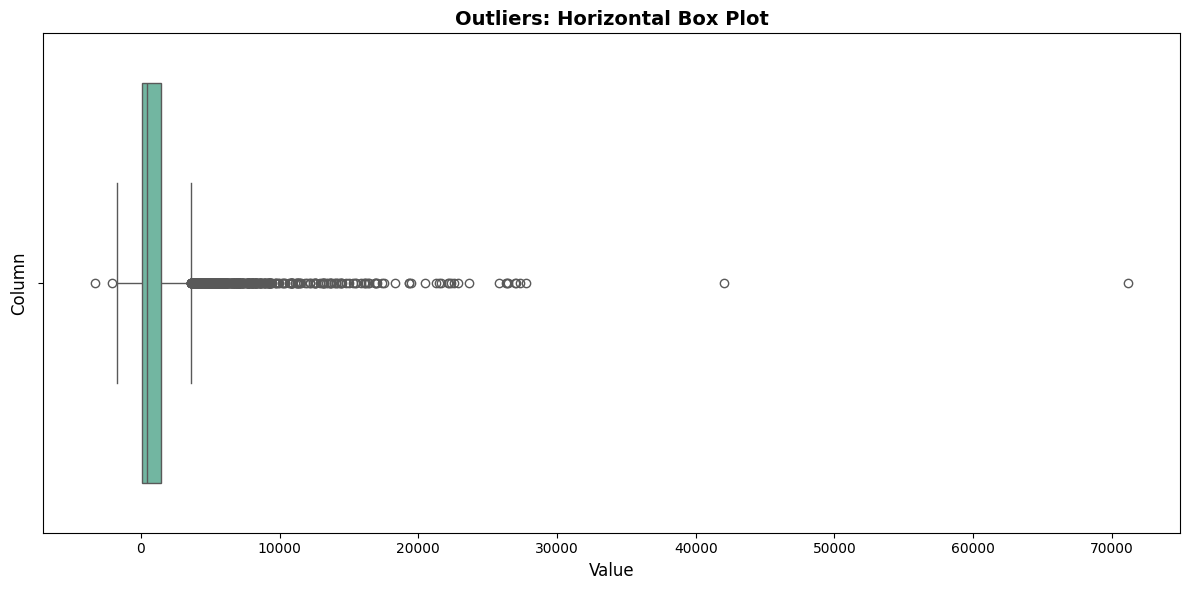

In [40]:
# 2) 
plt.figure(figsize=(12, 6))

# Create horizontal box plot
sns.boxplot(data=df["balance"], orient='h', palette='Set2')

plt.title('Outliers: Horizontal Box Plot', fontsize=14, fontweight='bold')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Column', fontsize=12)
plt.tight_layout()
plt.show()

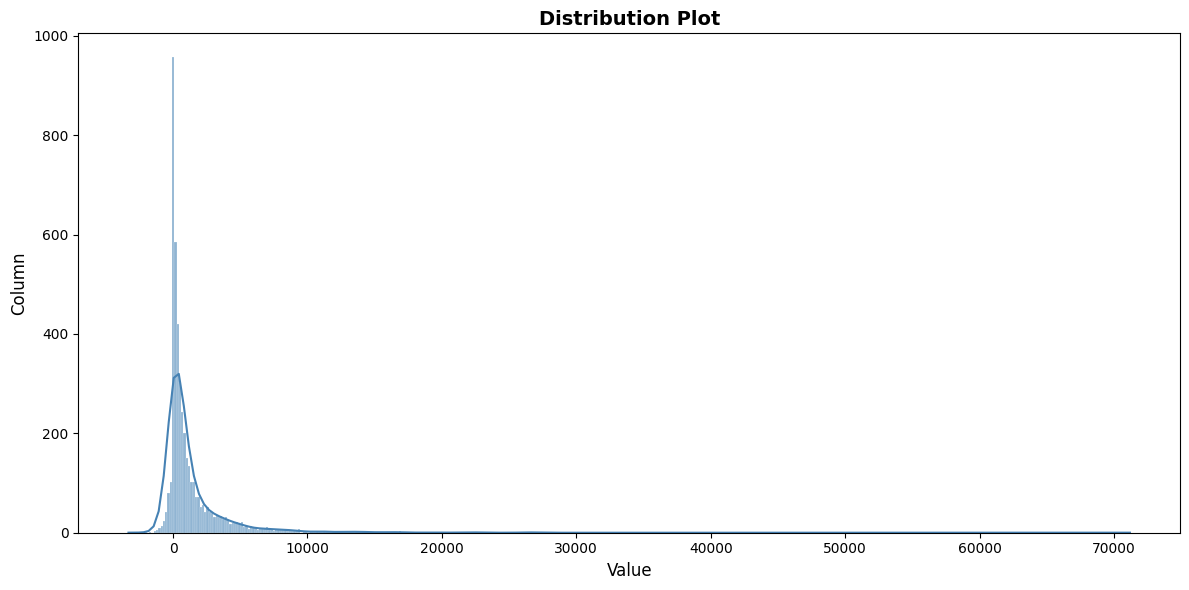

In [41]:
# 2) 
plt.figure(figsize=(12, 6))

# Create horizontal box plot
# sns.(data=df["balance"], orient='h', palette='Set2')
sns.histplot(df["balance"], kde=True, color='steelblue', edgecolor='white', alpha=0.6)

plt.title('Distribution Plot', fontsize=14, fontweight='bold')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Column', fontsize=12)
plt.tight_layout()
plt.show()

In [42]:
# 3) ✅ Fix: Convert to float first, then clip
df["balance"] = df["balance"].astype(float)
df.loc[outlier_mask, "balance"] = df["balance"].clip(low, high)
print(f"  Balance outliers handled: {outlier_count}")

print("✅ Cleaning complete!")

  Balance outliers handled: 506
✅ Cleaning complete!


C:\Users\hi\AppData\Local\Temp\ipykernel_2636\1488021252.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df["balance"], orient='h', palette='Set2')


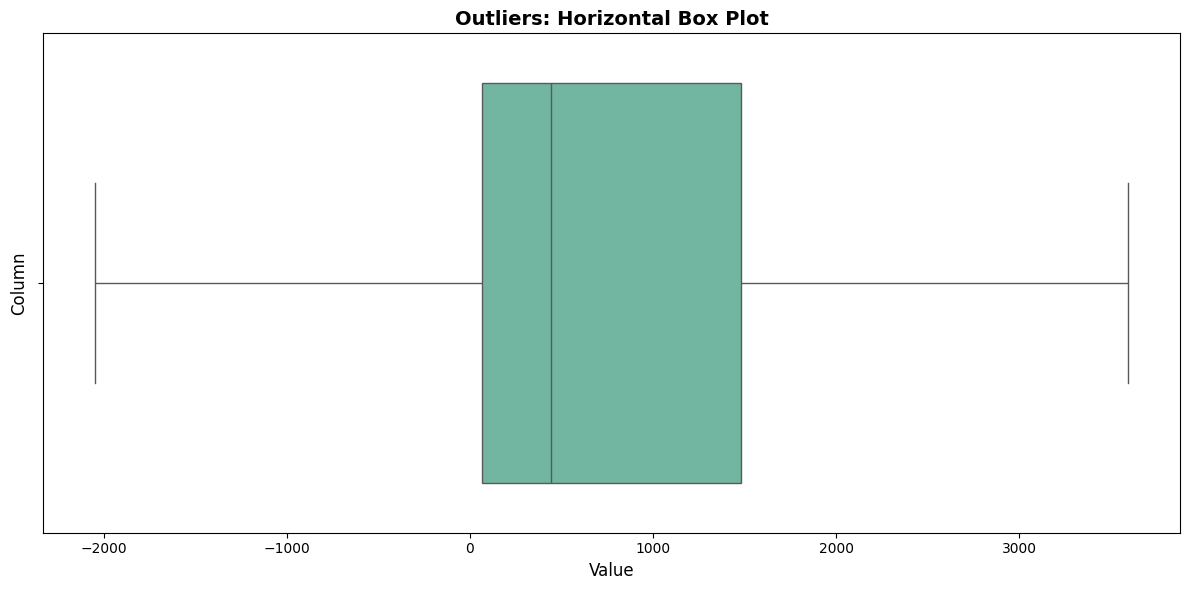

In [43]:
# 4) Plot after removing 

plt.figure(figsize=(12, 6))

# Create horizontal box plot
sns.boxplot(data=df["balance"], orient='h', palette='Set2')

plt.title('Outliers: Horizontal Box Plot', fontsize=14, fontweight='bold')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Column', fontsize=12)
plt.tight_layout()
plt.show()

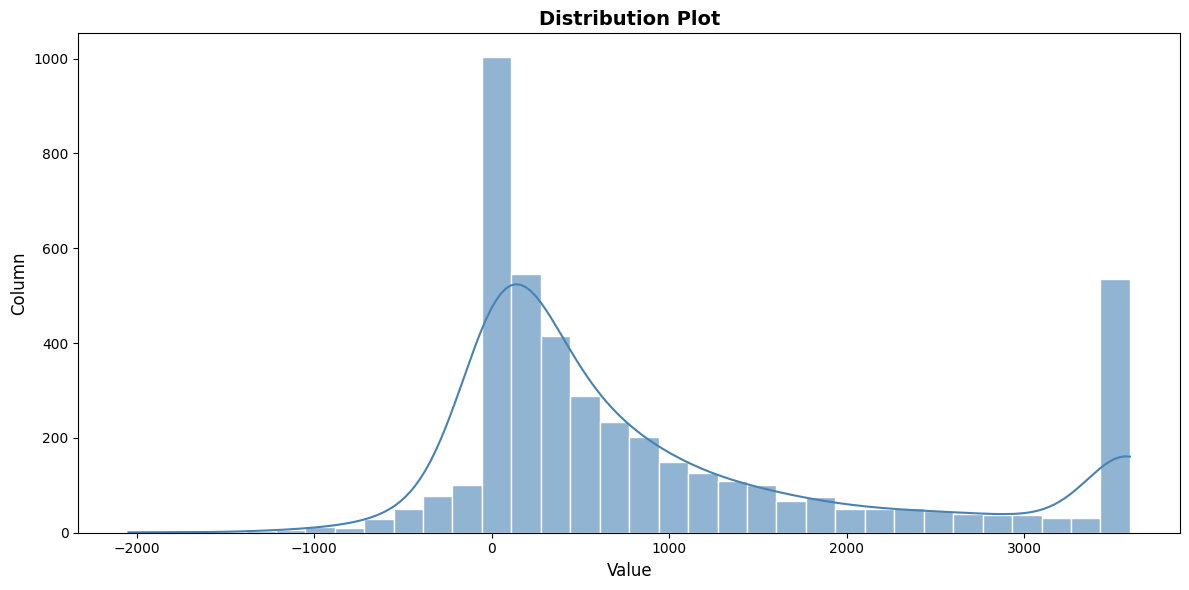

In [44]:
# 4) Plot after removing 
plt.figure(figsize=(12, 6))

# Create horizontal box plot
# sns.(data=df["balance"], orient='h', palette='Set2')
sns.histplot(df["balance"], kde=True, color='steelblue', edgecolor='white', alpha=0.6)

plt.title('Distribution Plot', fontsize=14, fontweight='bold')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Column', fontsize=12)
plt.tight_layout()
plt.show()

# Homework: Do this for other numeric columns

# STEP 4: DISPERSION & SKEWNESS

In [45]:
numeric_cols = df.select_dtypes(include=['int8', 'int16', 'int32', 'int64','float64']).columns

# Dispersion statistics
disp = df[numeric_cols].describe().T
disp['range'] = disp['max'] - disp['min']
disp['IQR'] = disp['75%'] - disp['25%']
print("\nDispersion (Spread):")
print(disp[['mean', 'std', 'range', 'IQR']])

# Skewness & Kurtosis
print("\nSkewness & Kurtosis:")
skew_kurt = pd.DataFrame({
    'skewness': df[numeric_cols].skew(),
    'kurtosis': df[numeric_cols].kurtosis()
})
print(skew_kurt)

# Interpretation
print("\nInterpretation:")
for col in skew_kurt.index:
    if abs(skew_kurt.loc[col, 'skewness']) > 1:
        print(f"  • {col}: Highly skewed (skew={skew_kurt.loc[col, 'skewness']:.2f}) - consider log transform")



Dispersion (Spread):
                mean          std   range     IQR
age        41.170095    10.576211    68.0    16.0
balance   973.493696  1240.356566  5644.0  1411.0
day        15.915284     8.247667    30.0    12.0
duration  263.961292   259.856633  3021.0   225.0
campaign    2.793630     3.109807    49.0     2.0
pdays      39.766645   100.121124   872.0     0.0
previous    0.542579     1.693562    25.0     0.0

Skewness & Kurtosis:
          skewness   kurtosis
age       0.699501   0.348775
balance   1.104876  -0.033045
day       0.094627  -1.039531
duration  2.772420  12.530050
campaign  4.743914  37.168920
pdays     2.717071   7.957128
previous  5.875259  51.995212

Interpretation:
  • balance: Highly skewed (skew=1.10) - consider log transform
  • duration: Highly skewed (skew=2.77) - consider log transform
  • campaign: Highly skewed (skew=4.74) - consider log transform
  • pdays: Highly skewed (skew=2.72) - consider log transform
  • previous: Highly skewed (skew=5.88) - c

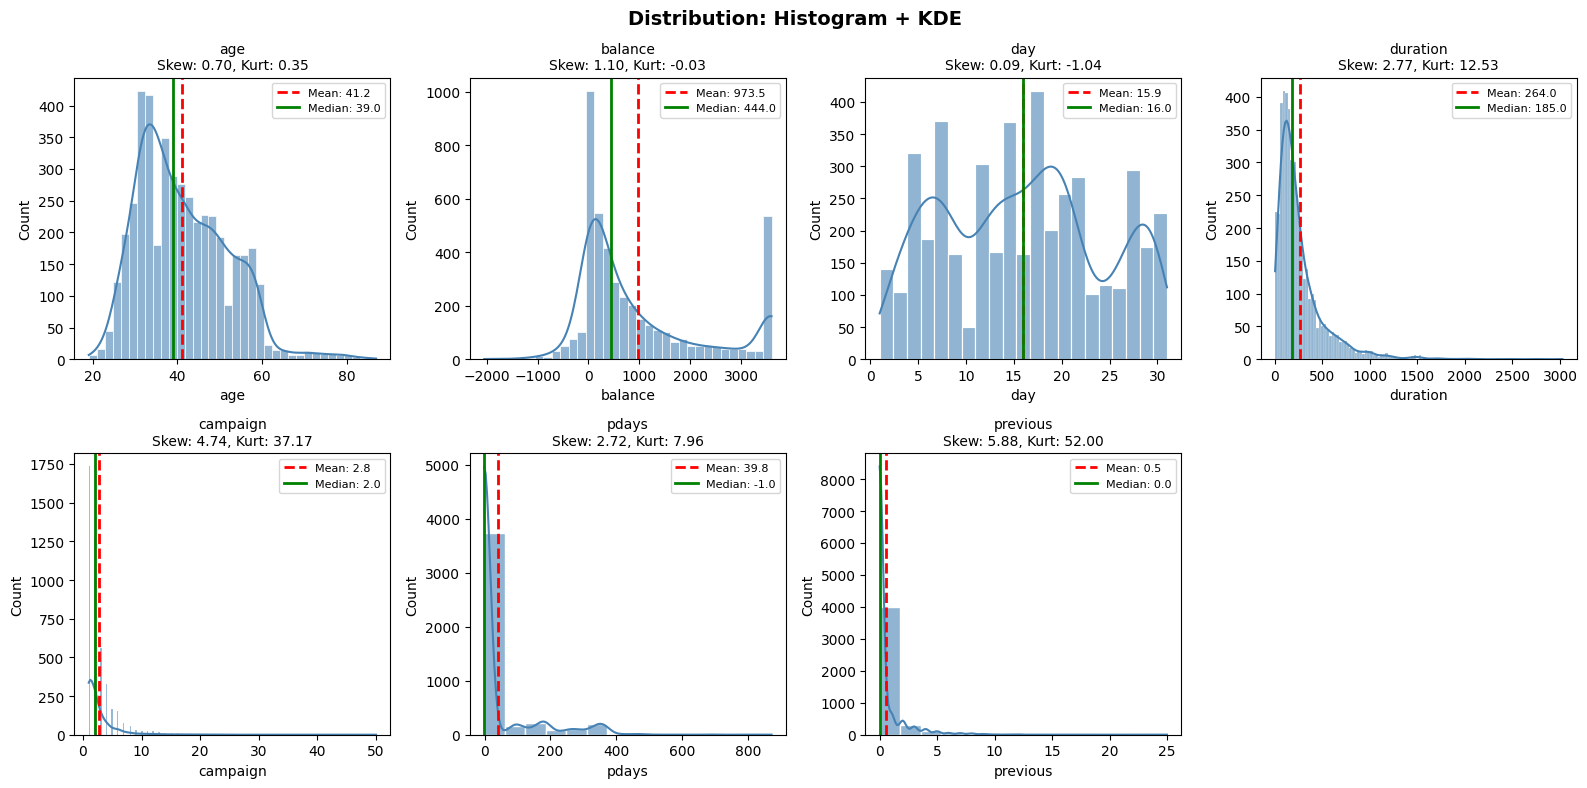

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get numeric columns
numeric_cols = df.select_dtypes(include=['int8', 'int16', 'int32', 'int64','float64']).columns

# Create figure
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Plot histogram + KDE
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.6)
    
    # Calculate stats
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    mean = df[col].mean()
    std = df[col].std()
    
    # Add vertical lines for mean and median
    ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.1f}')
    ax.axvline(df[col].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df[col].median():.1f}')
    
    # Add title with skewness
    ax.set_title(f'{col}\nSkew: {skew:.2f}, Kurt: {kurt:.2f}', fontsize=10)
    ax.legend(fontsize=8)

# Hide empty subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution: Histogram + KDE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# STEP 5: DATA PRE-PROCESSING

In [47]:
# a) Binary encode yes/no columns
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])
    print(f"  {col}: binary encoded")

# b) One-hot encode multi-class categorical columns
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"  One-hot encoded: {cat_cols}")

# c) Scale numeric features
num_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])
print(f"  Scaled: {num_features}")

print(f"\nFinal shape: {df.shape}")

  default: binary encoded
  housing: binary encoded
  loan: binary encoded
  y: binary encoded
  One-hot encoded: ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
  Scaled: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

Final shape: (4521, 39)


In [48]:
df.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration',
       'campaign', 'pdays', 'previous', 'y', 'job_Blue-Collar',
       'job_Entrepreneur', 'job_Housemaid', 'job_Management', 'job_Retired',
       'job_Self-Employed', 'job_Services', 'job_Student', 'job_Technician',
       'job_Unemployed', 'marital_Married', 'marital_Single',
       'education_Secondary', 'education_Tertiary', 'contact_Telephone',
       'month_Aug', 'month_Dec', 'month_Feb', 'month_Jan', 'month_Jul',
       'month_Jun', 'month_Mar', 'month_May', 'month_Nov', 'month_Oct',
       'month_Sep', 'poutcome_Other', 'poutcome_Success'],
      dtype='object')

In [49]:
df

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_Jan,month_Jul,month_Jun,month_Mar,month_May,month_Nov,month_Oct,month_Sep,poutcome_Other,poutcome_Success
0,-1.056270,0,0.655937,0,0,19,-0.711861,-0.576829,-0.407218,-0.320413,...,False,False,False,False,False,False,True,False,False,False
1,-0.772583,0,2.114953,1,1,11,-0.169194,-0.576829,2.989044,2.041734,...,False,False,False,False,True,False,False,False,False,False
2,-0.583458,0,0.303580,1,0,16,-0.303898,-0.576829,2.899143,0.270124,...,False,False,False,False,False,False,False,False,False,False
3,-1.056270,0,0.405175,1,1,3,-0.250017,0.387967,-0.407218,-0.320413,...,False,False,True,False,False,False,False,False,False,False
4,1.686036,0,-0.784937,1,0,5,-0.146102,-0.576829,-0.407218,-0.320413,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,-0.772583,0,-1.053438,1,0,30,0.250315,0.709566,-0.407218,-0.320413,...,False,True,False,False,False,False,False,False,False,False
4517,1.496912,1,-2.435854,1,1,9,-0.427057,-0.576829,-0.407218,-0.320413,...,False,False,False,False,True,False,False,False,False,False
4518,1.496912,0,-0.547076,0,0,19,-0.434754,2.639160,-0.407218,-0.320413,...,False,False,False,False,False,False,False,False,False,False
4519,-1.245394,0,0.131837,0,0,6,-0.519426,0.387967,1.710451,1.451197,...,False,False,False,False,False,False,False,False,True,False


# STEP 6: DATA MANIPULATION

In [57]:
print("STEP 6: DATA MANIPULATION")

# a) Subsetting
subset = df[['age', 'balance', 'y']].head(10)
print("\na) Subsetting (first 10 rows):")
print(subset)

# b) Grouping
# (Using the scaled data - note 'y' is now 0/1)
grouped = df.groupby('y')[['balance', 'duration']].mean()
print("\nb) Group by target (y):")
print(grouped)

# c) Pivot table
# Recreate original y for demonstration (not scaled)
# Note: In practice, you'd keep a copy of y before scaling
print("\nc) Pivot table example:")
pivot = pd.pivot_table(df, index='y', columns='housing', values='duration', aggfunc='mean')
print(pivot)

STEP 6: DATA MANIPULATION

a) Subsetting (first 10 rows):
        age   balance  y
0 -1.056270  0.655937  0
1 -0.772583  2.114953  0
2 -0.583458  0.303580  0
3 -1.056270  0.405175  0
4  1.686036 -0.784937  0
5 -0.583458 -0.182624  0
6 -0.488896 -0.537400  0
7 -0.205209 -0.666409  0
8 -0.016085 -0.606742  0
9  0.173040 -0.855892  0

b) Group by target (y):
    balance  duration
y                    
0 -0.026372 -0.144764
1  0.202470  1.111434

c) Pivot table example:
housing         0         1
y                          
0       -0.181097 -0.118963
1        0.882167  1.425113


# STEP 7: ADVANCED MANIPULATION

In [31]:
# Reload a fresh copy for advanced manipulation (to show original values)
import zipfile
import pandas as pd

# Path to your zip file
zip_path = 'data_bank.zip'

# 1. Open the zip file and show all file names
with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files in zip:", z.namelist())
    
    # 2. Read only 'bank.csv' into a DataFrame
    with z.open('bank.csv') as f:
        df2 = pd.read_csv(f,  sep=";")

# Display the first few rows of the DataFrame
print(df2.head())

# a) Feature engineering: create new variables
df2['balance_per_age'] = df2['balance'] / (df2['age'] + 1)
df2['log_balance'] = np.log1p(df2['balance'].clip(lower=0))  # log(1+x), handle zeros
print("a) New features created:")
print(df2[['age', 'balance', 'balance_per_age', 'log_balance']].head())

# b) Binning: convert continuous to categorical
df2['age_bracket'] = pd.cut(
    df2['age'], 
    bins=[0, 25, 35, 50, 100], 
    labels=['Young', 'Adult', 'Middle', 'Senior']
)
print("\nb) Binning 'age' into brackets:")
print(df2['age_bracket'].value_counts())

# c) Conditional transformations
df2.loc[df2['balance'] < 0, 'balance_category'] = 'Negative'
df2.loc[df2['balance'] == 0, 'balance_category'] = 'Zero'
df2.loc[df2['balance'] > 0, 'balance_category'] = 'Positive'
print("\nc) Conditional transformation:")
print(df2['balance_category'].value_counts())

print("\n" + "=" * 50)
print("✅ EDA COMPLETE!")
print("=" * 50)

Files in zip: ['bank-full.csv', 'bank-names.txt', 'bank.csv']
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
a) New features created:
   age  balance  balance